# <font color='ff006e'>Where Should I Live? #

### Programming for Data Science Project | 2025-2026 ###
**Group 17** - Ana Silva (20241822), Beatriz Alves (20241747), Inês Claro (20241760), Inês Graça (20241786)

### <font color='ff006e'>Table of Contents </font> <a class="anchor" id='toc'></a> 

- [1. Project Description](#P1) 
- [2. Data Wrangling and Analysis](#P2)

### <font color='ff006e'>Project Description ###

This project aims to assist individuals in the decision-making process regarding where to live in Europe by analysing country related data trough **Data Wrangling**, **Exploratory Analysis** and **Visualisation Techniques**. This way, individuals can assess the insights provided and evaluate them based on their own personal interests and priorities, facilitating more informed decisions. 

### <font color='ff006e'>Data Wrangling and Analysis ###

This stage includes **importing**, **comprehending** and **preprocessing** raw data included in the *city_data.csv* file, transforming it into a uniform dataset.

**Step 1:** Import all the libraries needed.

In [261]:
import pandas as pd 
import datetime as datetime
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler

**Step 2:** Import the file *city_data.csv* to the variable *original_data*. By analysing the file, it is possible to see that the separator is a vertical bar (|) and that the relevant header is in the first row and that the actual header of the file is not needed (*Unnamed* row). Additionaly, it is possible to see that the last column of our dataset (`Last Data Update`) is a date, so the file can be imported with this specification.

In [262]:
original_data = pd.read_csv(r"city_data.csv", sep ="|", header = 1, parse_dates = ["Last Data Update"])
original_data

,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
0,"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15
1,"Salzburg, Austria",243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03
2,"Brussels, Belgium",681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22
3,"Antwerp, Belgium",928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09
4,"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,"Stockholm, Sweden",334.0,2344124,1534225.0,28.5,6.2,70950.0,0,"Swedish, English",2700,1400,2300,NaN,2024-09-11
82,"Gothenburg, Sweden",245.0,1037675,672152.0,28.2,6.3,49588.0,0,"Swedish, English",2500,1200,2100,NaN,2023-03-10
83,"Malmo, Sweden",368.0,680335,436271.0,29.4,9.2,44387.0,0,"Swedish, English",2400,1100,2000,NaN,2024-07-07
84,"Ankara, Turkiye",1922.0,4843511,3417691.0,30.0,14.4,38916.0,3,Turkish,900,450,900,309.0,2023-06-08


**Step 3:** Create a copy of the original dataset (this step is done to ensure any mistakes made during this phase do not affect the original dataset) and analyse it.

In [263]:
data_copy = original_data.copy()
data_copy

,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
0,"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15
1,"Salzburg, Austria",243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03
2,"Brussels, Belgium",681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22
3,"Antwerp, Belgium",928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09
4,"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,"Stockholm, Sweden",334.0,2344124,1534225.0,28.5,6.2,70950.0,0,"Swedish, English",2700,1400,2300,NaN,2024-09-11
82,"Gothenburg, Sweden",245.0,1037675,672152.0,28.2,6.3,49588.0,0,"Swedish, English",2500,1200,2100,NaN,2023-03-10
83,"Malmo, Sweden",368.0,680335,436271.0,29.4,9.2,44387.0,0,"Swedish, English",2400,1100,2000,NaN,2024-07-07
84,"Ankara, Turkiye",1922.0,4843511,3417691.0,30.0,14.4,38916.0,3,Turkish,900,450,900,309.0,2023-06-08


In [264]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   City                             86 non-null     object        
 1   Population Density               85 non-null     float64       
 2   Population                       86 non-null     int64         
 3   Working Age Population           85 non-null     float64       
 4   Youth Dependency Ratio           86 non-null     float64       
 5   Unemployment Rate                85 non-null     float64       
 6   GDP per Capita                   85 non-null     float64       
 7   Days of very strong heat stress  86 non-null     int64         
 8   Main Spoken Languages            85 non-null     object        
 9   Average Monthly Salary           86 non-null     int64         
 10  Avgerage Rent Price              86 non-null     int64         


In [265]:
data_copy.rename(columns={'Avgerage Rent Price': 'Average Rent Price', 'Working Age Population ':'Working Age Population'}, inplace=True)

By using the `info` method, it is possible to check the number of rows, columns, missing values and data types of our dataset. We conclude there are 6 columns with missing values (`Population Density` (1), `Working Age Population` (1), `Unemployment Rate`(1), `GDP per Capita` (1), `Main Spoken Languages` (1) and `Average Price Groceries` (80)). We also noticed that the DataFrame had a typo in the column `Average Rent Price` and an extra blank space in `Working Age Population`, so we corrected it.

**Step 4:** Correct some errors in the dataset, so that it is uniform throughout all the rows.

**4.1**: Replace the separators in the columns `City` and `Main Spoken Languages`, so that all separators are ','.

In [266]:
data_copy['City'] = data_copy['City'].str.replace('.',',', regex = False)
data_copy['City'] = data_copy['City'].str.replace(';',',', regex = False)
data_copy['Main Spoken Languages'] = data_copy['Main Spoken Languages'].str.replace(';',',')

**4.2**: Split the column `City` into `Country` and `City` and remove any unnecessary white spaces in this columns' data. For convenience, the order of these 2 columns was also switched.

In [267]:
#split the column City in two: the column City and the column Country
data_copy[['City', 'Country']] = data_copy['City'].str.split(',', expand=True)

#remove unnecessary white spaces in the columns' data
data_copy['City'] = data_copy['City'].apply(lambda x: x.strip())
data_copy['Country'] = data_copy['Country'].apply(lambda x: x.strip())

#switch the order they appear on the dataset
country_col = data_copy.pop('Country')
data_copy.insert(0,'Country', country_col)
data_copy

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
0,Austria,Vienna,310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15
1,Austria,Salzburg,243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03
2,Belgium,Brussels,681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22
3,Belgium,Antwerp,928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09
4,Belgium,Gent,552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,Sweden,Stockholm,334.0,2344124,1534225.0,28.5,6.2,70950.0,0,"Swedish, English",2700,1400,2300,NaN,2024-09-11
82,Sweden,Gothenburg,245.0,1037675,672152.0,28.2,6.3,49588.0,0,"Swedish, English",2500,1200,2100,NaN,2023-03-10
83,Sweden,Malmo,368.0,680335,436271.0,29.4,9.2,44387.0,0,"Swedish, English",2400,1100,2000,NaN,2024-07-07
84,Turkiye,Ankara,1922.0,4843511,3417691.0,30.0,14.4,38916.0,3,Turkish,900,450,900,309.0,2023-06-08


**Step 5**: Fill in the missing value (it is a MCAR - Missing Completely at Random) in the column `Main Spoken Languages` with the associated country's mode and normalize the data in that column by removing unnecessary white spaces.

In [268]:
data_copy['Main Spoken Languages'] = (
    data_copy.groupby('Country')['Main Spoken Languages'].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else 'Unknown'))
data_copy['Main Spoken Languages'] = data_copy['Main Spoken Languages'].apply(lambda x: x.strip())

**Step 6**: Impute missing values in the columns `Population Density`, `Working Age Population`, `GDP per Capita` and `Unemployment Rate`. For these columns, since the missing values are MCAR (Missing Completely at Random) and the variables which they belong to are numerical, they will be filled with the median value (less affected by outliers) of the associated country.

In [269]:
for column in ['Population Density', 'Working Age Population', 'GDP per Capita', 'Unemployment Rate']:
    data_copy[column] = data_copy.groupby('Country')[column].transform(lambda x: x.fillna(x.median()))

**Step 7:** Drop the column `Average Price Groceries` - This column will be removed since the majority of the values (80) are missing values.

In [270]:
data_copy = data_copy.drop(columns = "Average Price Groceries", axis = 1)
data_copy

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
0,Austria,Vienna,310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15
1,Austria,Salzburg,243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,2023-11-03
2,Belgium,Brussels,681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22
3,Belgium,Antwerp,928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09
4,Belgium,Gent,552.0,645813,417832.0,24.8,6.2,53311.0,2,"Dutch, French",2400,827,1200,2023-07-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,Sweden,Stockholm,334.0,2344124,1534225.0,28.5,6.2,70950.0,0,"Swedish, English",2700,1400,2300,2024-09-11
82,Sweden,Gothenburg,245.0,1037675,672152.0,28.2,6.3,49588.0,0,"Swedish, English",2500,1200,2100,2023-03-10
83,Sweden,Malmo,368.0,680335,436271.0,29.4,9.2,44387.0,0,"Swedish, English",2400,1100,2000,2024-07-07
84,Turkiye,Ankara,1922.0,4843511,3417691.0,30.0,14.4,38916.0,3,Turkish,900,450,900,2023-06-08


**NOTE**: It is possible to check now that our dataset no longer has missing values by using, again, the `info` method.

In [271]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Country                          86 non-null     object        
 1   City                             86 non-null     object        
 2   Population Density               86 non-null     float64       
 3   Population                       86 non-null     int64         
 4   Working Age Population           86 non-null     float64       
 5   Youth Dependency Ratio           86 non-null     float64       
 6   Unemployment Rate                86 non-null     float64       
 7   GDP per Capita                   86 non-null     float64       
 8   Days of very strong heat stress  86 non-null     int64         
 9   Main Spoken Languages            86 non-null     object        
 10  Average Monthly Salary           86 non-null     int64         


**Step 8:** Correct a specific row (46th row) where the City and Country entries are swapped.

In [272]:
data_copy["Country"].unique() 

array(['Austria', 'Belgium', 'Bulgaria', 'Switzerland', 'Cyprus',
       'Czechia', 'Germany', 'Denmark', 'Spain', 'Estonia', 'Finland',
       'France', 'United Kingdom', 'Athens', 'Greece', 'Croatia',
       'Hungary', 'Ireland', 'Italy', 'Luxembourg', 'Latvia', 'Malta',
       'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania',
       'Slovak Republic', 'Slovenia', 'Sweden', 'Turkiye'], dtype=object)

In [273]:
data_copy.query("Country == 'Athens'")

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
45,Athens,Greece,1829.0,3530371,2287174.0,22.0,17.2,38580.0,17,"Greek, English",1050,600,1200,2024-07-16


Using the `unique()` and `query()` methods, we checked that 'Athens' and 'Greece' were swapped. This row will be manually corrected.

In [274]:
wrong_name = 45 
data_copy.loc[wrong_name, ['Country','City']] = data_copy.loc[wrong_name, ['City','Country']].values
data_copy.iloc[[45]] # check if the correction happened

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
45,Greece,Athens,1829.0,3530371,2287174.0,22.0,17.2,38580.0,17,"Greek, English",1050,600,1200,2024-07-16


**Step 9:** Search and drop duplicate rows.

In [275]:
data_copy[data_copy.duplicated()]

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
16,Germany,Berlin,304.0,5303922,3481212.0,21.3,4.7,46548.0,3,"German, Turkish, Arabic, English",3200,1220,2200,2023-06-29
33,Spain,Malaga,571.0,869096,585608.0,23.5,17.7,27694.0,0,"Spanish, English",2200,1312,1400,2023-11-27


In [276]:
data_copy.drop_duplicates(inplace=True)
data_copy[data_copy.duplicated()] # confirm all duplicates are dropped

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update


<div class="alert alert-block alert-info"> 

#### Question 1: How did you handle missing values and duplicate records in the dataset? Justify your approach.

Regarding missing values, they were detected using the `info()` method. The column `Average Price Groceries` was removed since it consisted mostly of missing values. The missing values in the columns `Population Density`, `Working Age Population`, `GDP per Capita` and `Unemployment Rate` were imputed using the median values for each country and missing values in `Main Spoken Languages` were imputed with the mode of the associated country. Duplicate records were identified in the dataset and removed.
</div>

**Step 10:** Find the number of countries and cities that exist in the dataset.

In [277]:
data_copy.describe(include = 'object')

,Country,City,Main Spoken Languages
count,84,84,84
unique,30,84,54
top,Germany,Vienna,Italian
freq,10,1,6


There are a total of 30 countries and 84 cities. The most frequent country in the dataset is **Germany** (with 10 cities).

<div class="alert alert-block alert-info"> 

#### Question 2: a) Which country appears most frequently in the dataset? How many cities are associated with it?
The country that appears more frequently in the dataset is Germany and there are 10 cities associated with it.
</div>

**Step 11**: Group the number of cities by country to determine how many cities are associated with each country.

In [278]:
number_of_cities_per_country = data_copy.groupby("Country")["City"].count()
print(number_of_cities_per_country)
print(f"Greece is associated with {number_of_cities_per_country["Greece"]} cities")

Country
Austria             2
Belgium             4
Bulgaria            2
Croatia             2
Cyprus              2
Czechia             2
Denmark             2
Estonia             1
Finland             2
France              3
Germany            10
Greece              2
Hungary             3
Ireland             2
Italy               6
Latvia              1
Luxembourg          1
Malta               1
Netherlands         5
Norway              3
Poland              3
Portugal            4
Romania             1
Slovak Republic     1
Slovenia            1
Spain               5
Sweden              3
Switzerland         3
Turkiye             2
United Kingdom      5
Name: City, dtype: int64
Greece is associated with 2 cities


<div class="alert alert-block alert-info"> 

#### Question 2: b) How many cities are present in total? How many are associated with Greece?
There are **84 cities in total** and **2** of them are associated with **Greece**.
</div>

**Step 12**: Sort the columns `City` and `Country` alphabetically.

In [279]:
data_copy = data_copy.sort_values(by=['Country','City'], ignore_index = True)
data_copy

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
0,Austria,Salzburg,243.0,375489,250472.0,20.30,3.0,66689.0,0,German,3200,1100,2186,2023-11-03
1,Austria,Vienna,310.0,2983513,2018818.0,20.10,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15
2,Belgium,Antwerp,928.0,1139663,723396.0,27.70,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09
3,Belgium,Bruges,840.0,119765,74600.0,25.63,5.6,63083.0,0,"Dutch, French",2700,1250,1708,2023-10-25
4,Belgium,Brussels,681.0,3284548,2137425.0,27.50,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,United Kingdom,Edinburgh,527.0,907580,614959.0,23.40,3.7,54002.0,0,"English, Scots Gaelic",2500,1010,2050,2023-08-15
80,United Kingdom,Glasgow,548.0,1845020,1229657.0,24.20,4.8,39666.0,0,"English, Scots",2300,1050,1950,2023-05-28
81,United Kingdom,Leeds,517.0,2641062,1677791.0,30.00,3.5,37990.0,0,"English, Urdu",2300,1000,2000,2024-11-03
82,United Kingdom,Liverpool,1560.0,1544216,983056.0,26.80,7.5,33749.0,0,English,2250,950,1800,2024-01-23


**Step 13**: Create a new dataframe with the columns `Country` and `Main Spoken Languages` to calculate how many countries speak each language.

**13.1**: Separate the `Main Spoken Languages` so that each row corresponds to just one language. Remove any white spaces the column `Language`'s data might contain as well as duplicates, making each language appear only once.

In [280]:
languages = data_copy[['Country', 'Main Spoken Languages']].copy() # new dataframe with columns "Country" and "Main Spoken Languages"
languages['Language'] = languages['Main Spoken Languages'].str.split(',') # more than one language can be spoken by each country - separated by ',' in the dataset
languages = languages[['Country','Language']].explode('Language') # one language per row

languages['Language'] = languages['Language'].str.strip() # remove white spaces
languages.drop_duplicates(inplace=True) #remove duplicates

**13.2**: Count how many languages are spoken in each country (and group them by country) and store the result in the variable `count_languages_spoken`. Rename the count column to `Language Count` and sort the values so that the most spoken language appears first.

In [281]:
count_languages_spoken = languages.groupby(['Language']).count()['Country'] # count how many rows are associated w/ each language
count_languages_spoken = count_languages_spoken.to_frame(name = 'Language Count') # converts to a DataFrame
count_languages_spoken.sort_values('Language Count', ascending = False) # descending sorting

,Language Count
Language,
English,25
Turkish,5
German,4
French,4
Russian,3
Arabic,3
Swedish,2
Polish,2
Dutch,2


**13.3**: Identify the least spoken languages.

In [282]:
least_spoken_languages = count_languages_spoken[count_languages_spoken['Language Count'] == count_languages_spoken['Language Count'].min()]
print(f"The least spoken languages are {least_spoken_languages.index.tolist()}")

The least spoken languages are ['Bengali', 'Bulgarian', 'Catalan', 'Croatian', 'Czech', 'Danish', 'Estonian', 'Finnish', 'Hungarian', 'Irish Gaelic', 'Italian', 'Latvian', 'Luxembourgish', 'Maltese', 'Norwegian', 'Portuguese', 'Romanian', 'Scots', 'Scots Gaelic', 'Serbian', 'Slovak', 'Slovene', 'Spanish', 'Urdu', 'Valencian']


<div class="alert alert-block alert-info"> 

#### Question 2: c) Which is the least spoken language in the dataset? Which are the top 3 most spoken languages?
The 3 most spoken languages are **English** (25), **Turkish**(5), **German** and **French** (both German and French have a count of 4, so there is a tie for the 3rd place). The least spoken languages are the ones who have the minimum count value (1) - Slovak, Norwegian, Slovene, Spanish, Scots Gaelic, Scots, Urdu, Romanian, Portuguese, Serbian, Latvian, Maltese, Luxembourgish, Bengali, Italian, Irish Gaelic, Hungarian, Finnish, Estonian, Danish, Czech, Croatian, Catalan, Bulgarian and Valencian).
</div>

**Step 14**: Find out how many days ago was the last update for each city and which cities require an update (meaning which cities have entries that were uploaded prior to *April 2023*).

In [283]:
data_copy['Since Updated (in days)'] = (datetime.now() - data_copy['Last Data Update']).dt.days
cities_need_update = data_copy[data_copy['Last Data Update'] < '2023-04-01'] #check cities that the data wasn't updated before april 2023
city_list = cities_need_update['City'].tolist() #create list with cities that need to update data (data wasn't updated since april 2023)
print(f"Cities that require an update: {city_list}")

Cities that require an update: ['Lyon', 'Frankfurt am Main', 'Munich', 'Venice', 'Gothenburg', 'Basel']


<div class="alert alert-block alert-info"> 

#### Question 3: a) Entries uploaded before April 2023 need to be updated. Which cities would require an update?
The cities that need to update their data are **Lyon**, **Frankfurt am Main**, **Munich**, **Venice**, **Gothenburg** and **Basel**.
</div>

<div class="alert alert-block alert-info"> 

#### Question 3: b) How many days ago was the last update? On what day, month, and year did it occur?
The answer to this question is provided in the following line of code.
</div>

**Step 16**: Create a new pandas Series that, for each city that needs to update their data, displays how many days ago the last update was as well as the exact day, month and year. 

In [284]:
cities_need_update_copy = cities_need_update.copy() # so the following code is not executed on all cities

cities_need_update_copy['Day'] = cities_need_update_copy['Last Data Update'].dt.day
cities_need_update_copy['Month'] = cities_need_update_copy['Last Data Update'].dt.strftime('%B') # to give the name of the month
cities_need_update_copy['Year'] = cities_need_update_copy['Last Data Update'].dt.year


for line in (cities_need_update_copy['City'].astype(str) + ": The last update was " + cities_need_update_copy['Since Updated (in days)'].astype(str)
    + " days ago, on the day " + cities_need_update_copy['Day'].astype(str)
    + " of " + cities_need_update_copy['Month'].astype(str)
    + " of the year " + cities_need_update_copy['Year'].astype(str)
    + "."):
    print(line) # a for loop is used here because otherwise pandas would print it in a Series format

Lyon: The last update was 981 days ago, on the day 31 of March of the year 2023.
Frankfurt am Main: The last update was 1036 days ago, on the day 4 of February of the year 2023.
Munich: The last update was 996 days ago, on the day 16 of March of the year 2023.
Venice: The last update was 989 days ago, on the day 23 of March of the year 2023.
Gothenburg: The last update was 1002 days ago, on the day 10 of March of the year 2023.
Basel: The last update was 1052 days ago, on the day 19 of January of the year 2023.


### <font color='ff006e'>Data Visualization ###

**Step 1:** Check how the `Unemployment Rate` and `GDP per Capita` variables are distributed and related.

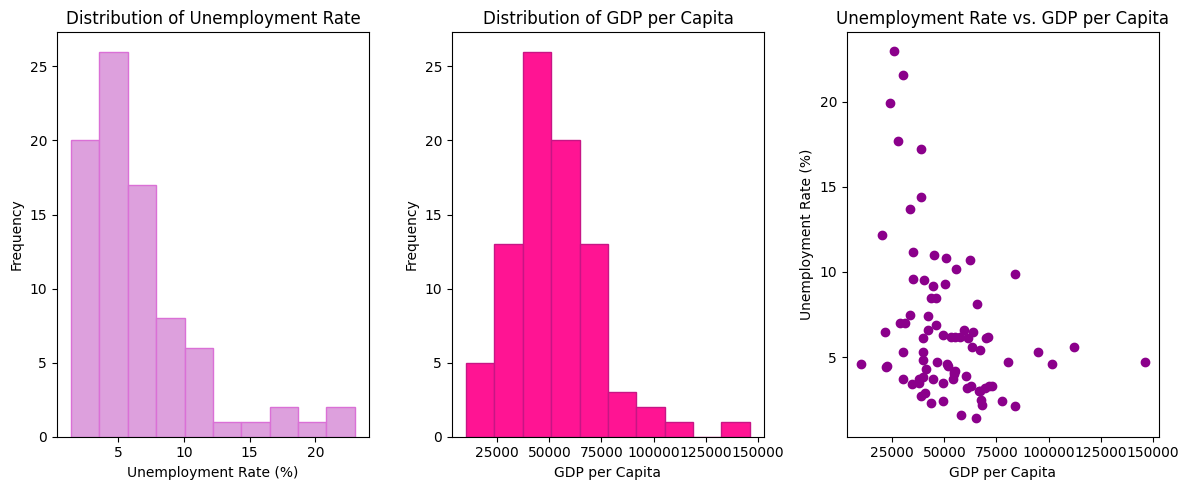

Correlation: -0.3466584086175857


In [285]:
fig, axs = plt.subplots(1, 3, figsize=(12, 5))
axs[0].hist(data_copy['Unemployment Rate'], color='plum', edgecolor='orchid')
axs[0].set_title('Distribution of Unemployment Rate')
axs[0].set_xlabel('Unemployment Rate (%)')
axs[0].set_ylabel('Frequency')

axs[1].hist(data_copy['GDP per Capita'], color='deeppink', edgecolor='mediumvioletred')
axs[1].set_title('Distribution of GDP per Capita')
axs[1].set_xlabel('GDP per Capita')
axs[1].set_ylabel('Frequency')

axs[2].scatter(data_copy['GDP per Capita'], data_copy['Unemployment Rate'], color = 'darkmagenta')
axs[2].set_title('Unemployment Rate vs. GDP per Capita')
axs[2].set_xlabel('GDP per Capita')
axs[2].set_ylabel('Unemployment Rate (%)')

plt.tight_layout()  # prevents overlapping of subplots
plt.show()

correlation = data_copy['GDP per Capita'].corr(data_copy['Unemployment Rate']) # calculate correlation
print(f"Correlation: {correlation}")


<div class="alert alert-block alert-info"> 

#### Question 4: a) How are the Unemployment Rate and GDP per Capita distributed and related? What does this relationship suggest? 
Based on the first 2 graphs, it is noticeable that both *Unemployment Rate* and *GDP per Capita* are **right skewed** (Unemployment more significantly than the latter), which indicates that while majority of the analysed cities have low *Unemployment Rate* and *GDP per Capita*, there are fewer cities that have higher values of these variables (skewing the distributions to the right). The last graph shows that these variables are **not highly correlated** (the dots are very sparse). It is observed a **negative**, although **weak**, relation, which is confirmed with the calculated **correlation (-0.347)**. This relationship suggests that wealthier cities (with a high *GDP per Capita*) tend to have fewer unemployed citizens (have a low *Unemployment Rate*). 
</div>

**Step 2**: Create a new column to store the difference between the `Average Monthly Salary` and the `Average Cost of Living` for each city.

In [286]:
data_copy['difference Avg. Monthly Salary and Avg. Cost of Living'] = data_copy['Average Monthly Salary']- data_copy['Average Cost of Living']
data_copy.head()

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update,Since Updated (in days),difference Avg. Monthly Salary and Avg. Cost of Living
0,Austria,Salzburg,243.0,375489,250472.0,20.30,3.0,66689.0,0,German,3200,1100,2186,2023-11-03,764,1014
1,Austria,Vienna,310.0,2983513,2018818.0,20.10,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15,539,439
2,Belgium,Antwerp,928.0,1139663,723396.0,27.70,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09,484,656
3,Belgium,Bruges,840.0,119765,74600.0,25.63,5.6,63083.0,0,"Dutch, French",2700,1250,1708,2023-10-25,773,992
4,Belgium,Brussels,681.0,3284548,2137425.0,27.50,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22,959,1450


**Step 3**: Determine the top 5 cities with the largest difference.

In [287]:
top5cities = data_copy.sort_values(by = 'difference Avg. Monthly Salary and Avg. Cost of Living', ascending = False)[["City", "difference Avg. Monthly Salary and Avg. Cost of Living"]].head()
top5cities

,City,difference Avg. Monthly Salary and Avg. Cost of Living
74,Basel,2127
18,Tampere,1900
17,Helsinki,1850
76,Zurich,1774
75,Geneva,1531


<div class="alert alert-block alert-info"> 

#### Question 4: b) Which are the top 5 cities with the largest difference between the `Average Monthly Salary` and `Average Cost of Living`?
The 5 cities with the largest difference between the `Average Monthly Salary` and `Average Cost of Living` are **Basel**, **Tampere**, **Helsinki**, **Zurich** and **Geneva**.
</div>

**Step 4**: Determine the top 5 countries with the smallest average difference.

In [288]:
bottom5countries = data_copy.groupby('Country')['difference Avg. Monthly Salary and Avg. Cost of Living'].mean().sort_values(ascending  = True).head()
bottom5countries

Country
Portugal          -207.500000
Greece            -125.000000
Slovak Republic    -50.000000
Turkiye            -25.000000
Poland             -16.666667
Name: difference Avg. Monthly Salary and Avg. Cost of Living, dtype: float64

<div class="alert alert-block alert-info"> 

#### Question 4: b) What about the top 5 countries with the smallest average difference?
The top 5 countries with the smallest average difference between the *Average Monthly Salary* and *Average Cost of Living* are **Portugal**, **Greece**, **SlovakRepublic**, **Turkiye** and **Poland**.
</div>

**Step 5**: Provide a visual representation of the previous 2 results.

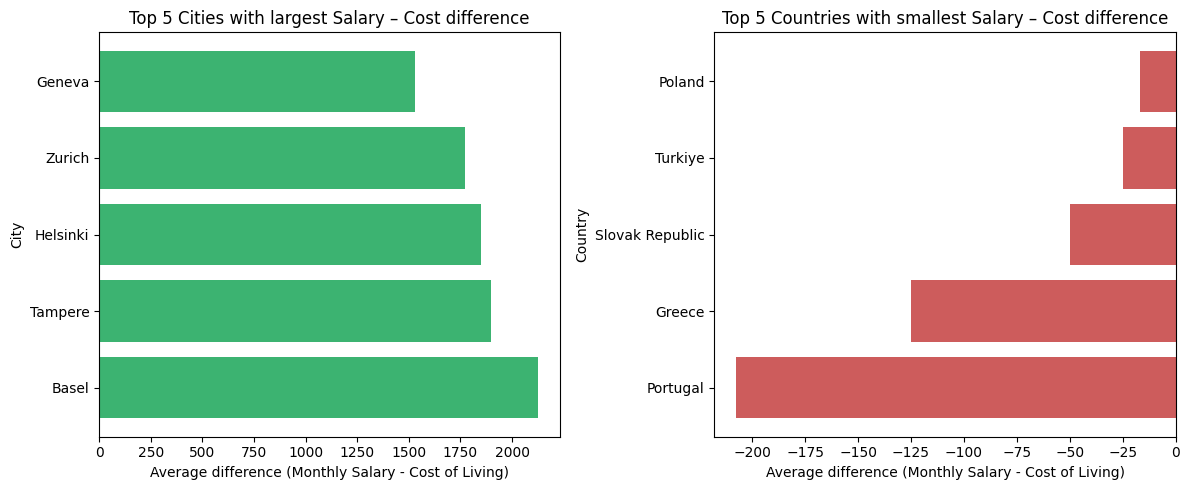

In [289]:
fig2, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].barh(top5cities["City"], top5cities["difference Avg. Monthly Salary and Avg. Cost of Living"], color='mediumseagreen')
axs[0].set_title('Top 5 Cities with largest Salary – Cost difference')
axs[0].set_xlabel('Average difference (Monthly Salary - Cost of Living)')
axs[0].set_ylabel('City')

axs[1].barh(bottom5countries.index, bottom5countries.values, color='indianred')
axs[1].set_title('Top 5 Countries with smallest Salary – Cost difference')
axs[1].set_xlabel('Average difference (Monthly Salary - Cost of Living)')
axs[1].set_ylabel('Country')

plt.tight_layout() # adjustment of space so elements do not overlap
plt.show()

**Step 6**: Determine the best city with specific characteristics:
- an `Average Monthly Salary` above €2000; 
- an `Average Cost of Living` below €1600;
- the lowest `Unemployment Rate` possible.

In [290]:
best_cities = data_copy[(data_copy['Average Monthly Salary'] > 2000) & (data_copy['Average Cost of Living'] <= 1600)].sort_values(by = 'Unemployment Rate', ascending = True)
print(f"The best city for someone looking for those specific characteristics is {best_cities.iloc[0,1]}, {best_cities.iloc[0,0]}.")
data_copy[data_copy["City"] == best_cities.iloc[0,1]][['Country','City','Average Monthly Salary','Average Cost of Living','Unemployment Rate']]

The best city for someone looking for those specific characteristics is Dresden, Germany.


,Country,City,Average Monthly Salary,Average Cost of Living,Unemployment Rate
24,Germany,Dresden,3050,1530,3.8


<div class="alert alert-block alert-info"> 

#### Question 4: c) Which is the best city for someone seeking: an `Average Monthly Salary` above €2000, a `Cost of Living` below €1600, and the lowest `Unemployment Rate` possible?
The best city for someone looking for those specific characteristics is Dresden, in Germany. The city has an `Average Montly Salary` of 3050€, an `Average Cost of Living` of €1530 and an `Unemployment Rate` of 3.8.
</div>

<div class="alert alert-block alert-info"> 

#### Question 5: What are three additional insights you find meaningful when comparing the given cities?
</div>

**Step 7**: Visualization of the relationship between `Average Cost of Living` and `GDP per Capita`.

In [291]:
data_copy['City,Country'] = data_copy['City'] + ', ' + data_copy['Country']

data_copy['Difference'] = data_copy['GDP per Capita'] - data_copy['Average Cost of Living']

plot_df = data_copy[['City,Country', 'GDP per Capita', 'Average Cost of Living', 'Difference']].copy()

# scaling numeric columns between 0 and 1
scaler = MinMaxScaler()
plot_df[['GDP per Capita', 'Average Cost of Living', 'Difference']] = scaler.fit_transform(
    plot_df[['GDP per Capita', 'Average Cost of Living', 'Difference']]
)

# we have to melt the dataframe to use on plotly
plot_long = plot_df.melt(id_vars='City,Country', 
                         value_vars=['GDP per Capita', 'Average Cost of Living', 'Difference'])


fig = px.line(
    plot_long,
    x='City,Country',
    y='value',
    color='variable',
    title='Difference between Cost of Living and GDP per Capita across cities',
    labels={'value': 'Scaled Value', 'variable': 'Variable', 'City,Country': 'City, Country'},
    color_discrete_map={
        'Average Cost of Living':'darkmagenta',
        'GDP per Capita':'mediumvioletred',
        'Difference':'darkgreen'
    }
)

fig.update_xaxes(tickangle=45)
fig.show()


As it is observed by the graph, the most affordable City (with the highest positive difference) is Cork in Ireland. On the other hand, the least affordable city is Dobrich in Bulgaria.

This insight is especially meaningful for this project because cities with higher `GDP per Capita` do not always represent a lower `Cost of Living`. In several cities, the `GDP per Capita` is close to the `Cost of Living`, which suggests that wealthy cities not always provide a bigger purchasing power for its residents.

**Step 8**: Visualization of the `Average Rent Price` - `Average Monthly Salary` ratio.

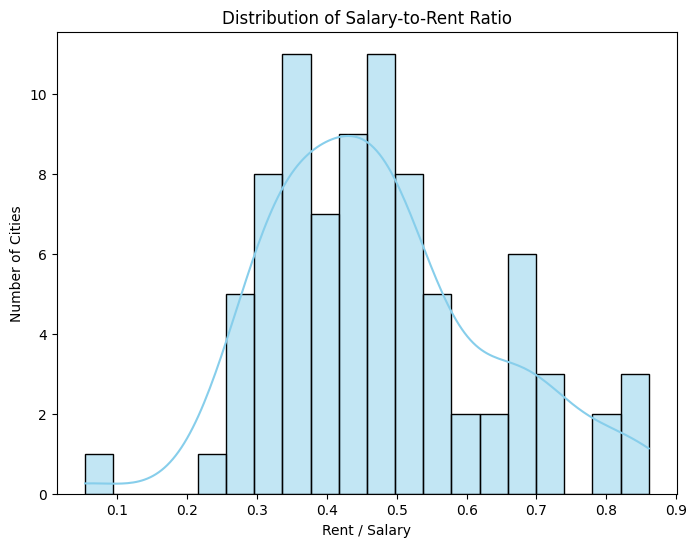

In [292]:
data_copy["rent-salary ratio"] = data_copy['Average Rent Price']/data_copy['Average Monthly Salary']
plt.figure(figsize=(8,6))
sns.histplot(data_copy["rent-salary ratio"], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Salary-to-Rent Ratio')
plt.xlabel('Rent / Salary')
plt.ylabel('Number of Cities')
plt.show()

Most cities have a `rent-salary ratio` near 0.4 and 0.5, meaning nearly half of the average salary is spent on rent. There are few cities where the ratio is really low (affordable cities) as well as some with higher ratios (with higher rent). This is relevant for this project since it measures the housing affordability for a working person and it reveals that not all cities with high `Average Monthly Salary` are truly affordable.

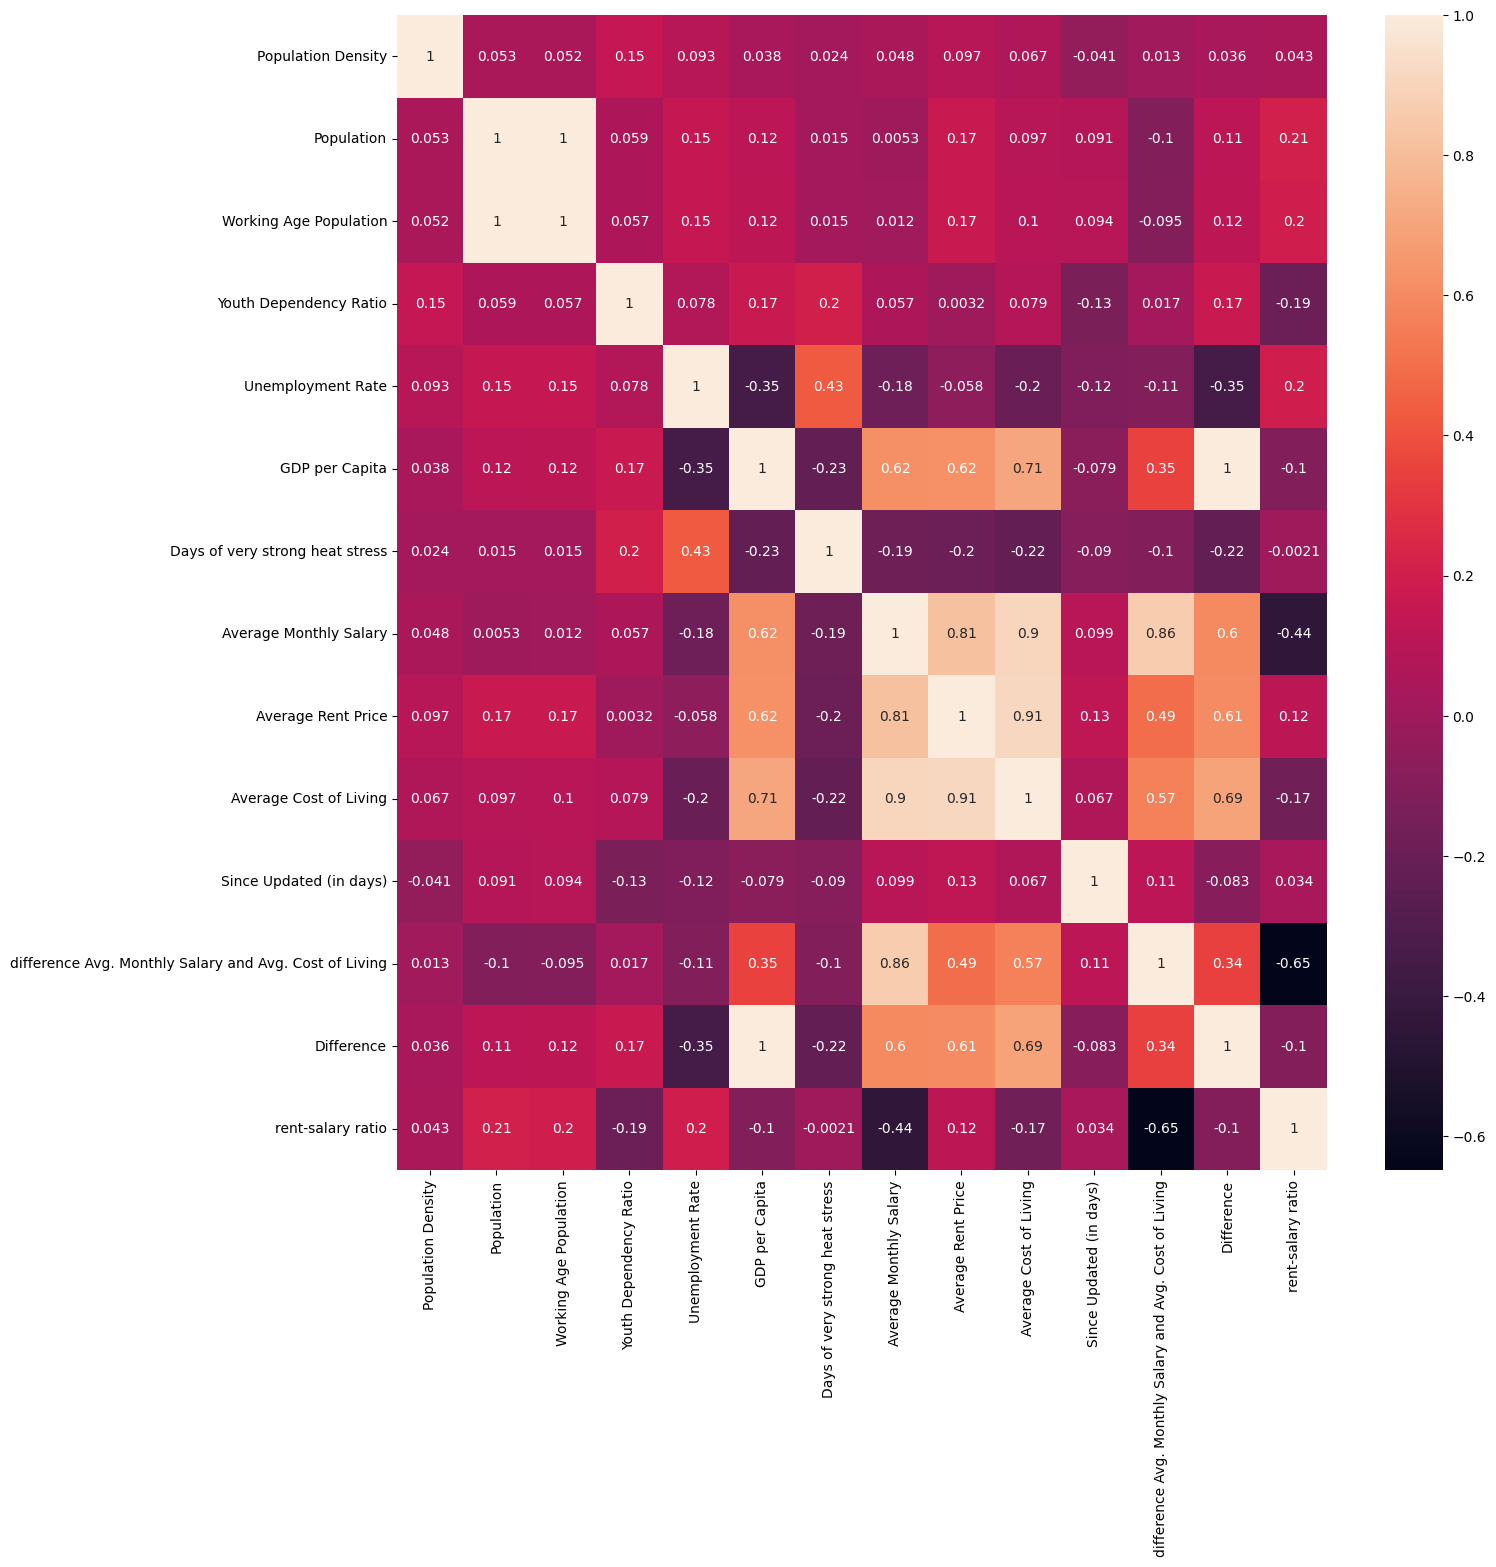

In [293]:
corr =data_copy.select_dtypes(include='number').corr()
fig, ax = plt.subplots(figsize=(15,15))
sns.heatmap(corr, annot=True)
plt.show()

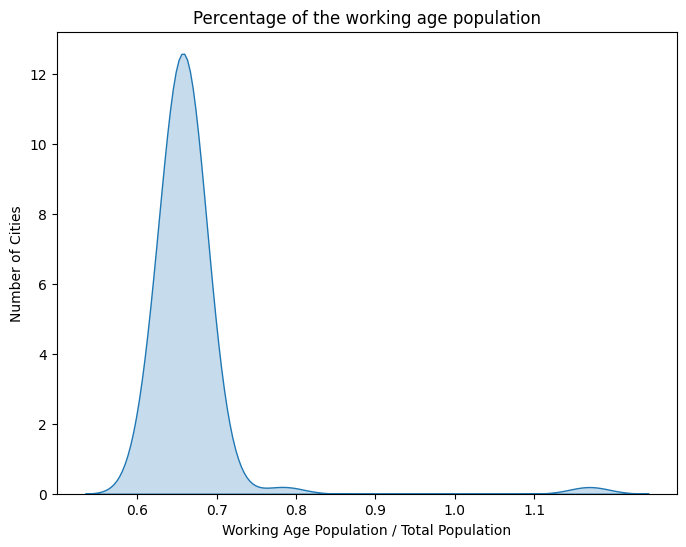

In [294]:
data_copy['working age population ratio'] = data_copy['Working Age Population'] / data_copy['Population']
plt.figure(figsize=(8,6))
sns.kdeplot(data_copy["working age population ratio"], fill=True)
plt.title('Percentage of the working age population')
plt.xlabel('Working Age Population / Total Population')
plt.ylabel('Number of Cities')
plt.xticks(np.arange(0.6, 1.1, 0.1))
plt.show()


In [295]:
fig = px.area(data_frame=data_copy, x='City', y='working age population ratio')
fig.show()

In [296]:
data_copy[data_copy['Working Age Population'] > data_copy['Population']]

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update,Since Updated (in days),difference Avg. Monthly Salary and Avg. Cost of Living,"City,Country",Difference,rent-salary ratio,working age population ratio
25,Germany,Dusseldorf,1295.0,1554077,1817524.0,21.4,3.3,71238.0,3,German,3200,1100,2050,2024-01-15,691,1150,"Dusseldorf, Germany",69188.0,0.34375,1.16952


This insight is important especially for working people, since a higher percentage of working means better job opportunities.

### <font color='ff006e'>Advanced Topic: Building an Interactive Map ###

#### <font color='ff006e'>Web Scraping ####

In [297]:
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options as Options_c
from selenium.common.exceptions import NoSuchElementException

url = 'https://en.wikipedia.org/wiki/Main_Page'
options = Options_c()
browser_c = webdriver.Chrome(options = options)

In [298]:
def coordinates(city):
    latitude, longitude = None, None
    try:
        city_url = f"https://en.wikipedia.org/wiki/{city.replace(' ', '_')}"
        browser_c.get(city_url)

        latitude = browser_c.find_element(By.CLASS_NAME, "latitude")
        latitude = latitude.text
        longitude = browser_c.find_element(By.CLASS_NAME, "longitude")
        longitude = longitude.text

        return latitude, longitude

    except NoSuchElementException:
        print(f"Coordinates not found for {city}.")
        pass

    except Exception as e:
        print(f"An unexpected error occurred for {city}: {e}")
        pass

    try:
        url_2 = f"https://en.wikipedia.org/wiki/{city}_(city)"
        browser_c.get(url_2)

        # Attempt to find and extract coordinates on the second page
        latitude = browser_c.find_element(By.CLASS_NAME, "latitude").text
        longitude = browser_c.find_element(By.CLASS_NAME, "longitude").text

    except NoSuchElementException:
        # Handle failure for the second URL
        print(f"INFO: Coordinates not found for {city} in both locations. Returning None.")
        # latitude and longitude remain None, as initialized.
    
    except Exception as e:
        # Catch any other unexpected error on the second attempt
        print(f"WARNING: Unexpected error during second attempt for {city}: {e}")
        # latitude and longitude remain None, as initialized.
            
    # Final return: Will return coordinates if found in step 2, or None, None otherwise.
    
    try:
        url_3 = f"https://pt.wikipedia.org/wiki/{city}"
        browser_c.get(url_3)

        # Attempt to find and extract coordinates on the second page
        full_coord_elem = browser_c.find_element(By.CLASS_NAME, "mw-kartographer-maplink")
        coord_parts = full_coord_elem.text.split(',')
        if len(coord_parts) == 2:
            # Remove leading/trailing spaces from split parts
            latitude = coord_parts[0].strip()
            longitude = coord_parts[1].strip()
            return latitude, longitude
                            
    except NoSuchElementException:
        # Handle failure for the second URL
        print(f"INFO: Coordinates not found for {city} in both locations. Returning None.")
        # latitude and longitude remain None, as initialized.
    
    except Exception as e:
        # Catch any other unexpected error on the second attempt
        print(f"WARNING: Unexpected error during second attempt for {city}: {e}")
        # latitude and longitude remain None, as initialized.
            
    # Final return: Will return coordinates if found in step 2, or None, None otherwise.

    return latitude, longitude


In [ ]:
list_cities = data_copy['City'].tolist()
dict_coordinates_city = {}
for city in list_cities:
    latitude, longitude = coordinates(city)
    dict_coordinates_city[city] = {'latitude': latitude, 'longitude': longitude}

dict_coordinates_city
res = not all(dict_coordinates_city.values())

# printing result
print("Does Dictionary contain None value ? " + str(res))

Coordinates not found for Gent.
INFO: Coordinates not found for Gent in both locations. Returning None.
Coordinates not found for Split.
Coordinates not found for Cork.
INFO: Coordinates not found for Cork in both locations. Returning None.
Coordinates not found for Madrid.
INFO: Coordinates not found for Madrid in both locations. Returning None.


{'Salzburg': {'latitude': '47°48′00″N', 'longitude': '13°02′42″E'},
 'Vienna': {'latitude': '48°12′30″N', 'longitude': '16°22′21″E'},
 'Antwerp': {'latitude': '51°13′04″N', 'longitude': '04°24′01″E'},
 'Bruges': {'latitude': '51°12′32″N', 'longitude': '03°13′27″E'},
 'Brussels': {'latitude': '50°50′48″N', 'longitude': '04°21′09″E'},
 'Gent': {'latitude': '51°03′13″N', 'longitude': '03°43′31″E'},
 'Dobrich': {'latitude': '43°34′N', 'longitude': '27°50′E'},
 'Sofia': {'latitude': '42°42′N', 'longitude': '23°20′E'},
 'Split': {'latitude': '43° 30′ 36″ N', 'longitude': '16° 26′ 24″ L'},
 'Zagreb': {'latitude': '45°48′47″N', 'longitude': '15°58′39″E'},
 'Lefkosia': {'latitude': '35°10′21″N', 'longitude': '33°21′54″E'},
 'Lemesos': {'latitude': '34°40′29″N', 'longitude': '33°02′39″E'},
 'Ostrava': {'latitude': '49°50′8″N', 'longitude': '18°17′33″E'},
 'Prague': {'latitude': '50°5′15″N', 'longitude': '14°25′17″E'},
 'Copenhagen': {'latitude': '55°40′34″N', 'longitude': '12°34′06″E'},
 'Odense

#### <font color='ff006e'>Interactive Map ####

In [303]:
dict_coordinates_city

{'Salzburg': {'latitude': '47°48′00″N', 'longitude': '13°02′42″E'},
 'Vienna': {'latitude': '48°12′30″N', 'longitude': '16°22′21″E'},
 'Antwerp': {'latitude': '51°13′04″N', 'longitude': '04°24′01″E'},
 'Bruges': {'latitude': '51°12′32″N', 'longitude': '03°13′27″E'},
 'Brussels': {'latitude': '50°50′48″N', 'longitude': '04°21′09″E'},
 'Gent': {'latitude': '51°03′13″N', 'longitude': '03°43′31″E'},
 'Dobrich': {'latitude': '43°34′N', 'longitude': '27°50′E'},
 'Sofia': {'latitude': '42°42′N', 'longitude': '23°20′E'},
 'Split': {'latitude': '43° 30′ 36″ N', 'longitude': '16° 26′ 24″ L'},
 'Zagreb': {'latitude': '45°48′47″N', 'longitude': '15°58′39″E'},
 'Lefkosia': {'latitude': '35°10′21″N', 'longitude': '33°21′54″E'},
 'Lemesos': {'latitude': '34°40′29″N', 'longitude': '33°02′39″E'},
 'Ostrava': {'latitude': '49°50′8″N', 'longitude': '18°17′33″E'},
 'Prague': {'latitude': '50°5′15″N', 'longitude': '14°25′17″E'},
 'Copenhagen': {'latitude': '55°40′34″N', 'longitude': '12°34′06″E'},
 'Odense

In [304]:
data_copy.columns

Index(['Country', 'City', 'Population Density', 'Population',
       'Working Age Population', 'Youth Dependency Ratio', 'Unemployment Rate',
       'GDP per Capita', 'Days of very strong heat stress',
       'Main Spoken Languages', 'Average Monthly Salary', 'Average Rent Price',
       'Average Cost of Living', 'Last Data Update', 'Since Updated (in days)',
       'difference Avg. Monthly Salary and Avg. Cost of Living',
       'City,Country', 'Difference', 'rent-salary ratio',
       'working age population ratio'],
      dtype='object')

In [331]:
#Create dataset with data ('Monthly Revenue' and 'Age') grouped by country
city = data_copy[data_copy.City.isin(dict_coordinates_city.keys())].groupby(['Country', 'City'])[['Population', 'Average Monthly Salary', 'Average Cost of Living']].mean().round(2).reset_index()

#Add latitude and longitude columnsity
city['lat'] = city['City'].map(lambda x: dict_coordinates_city[x]['latitude'])
city['lon'] = city['City'].map(lambda x: dict_coordinates_city[x]['longitude'])
city

,Country,City,Population,Average Monthly Salary,Average Cost of Living,lat,lon
0,Austria,Salzburg,375489.0,3200.0,2186.0,47°48′00″N,13°02′42″E
1,Austria,Vienna,2983513.0,2500.0,2061.0,48°12′30″N,16°22′21″E
2,Belgium,Antwerp,1139663.0,2609.0,1953.0,51°13′04″N,04°24′01″E
3,Belgium,Bruges,119765.0,2700.0,1708.0,51°12′32″N,03°13′27″E
4,Belgium,Brussels,3284548.0,3350.0,1900.0,50°50′48″N,04°21′09″E
...,...,...,...,...,...,...,...
79,United Kingdom,Edinburgh,907580.0,2500.0,2050.0,55°57′N,3°11′W
80,United Kingdom,Glasgow,1845020.0,2300.0,1950.0,55°51′40″N,04°15′00″W
81,United Kingdom,Leeds,2641062.0,2300.0,2000.0,53°47′51″N,01°32′37″W
82,United Kingdom,Liverpool,1544216.0,2250.0,1800.0,53°24′26″N,2°59′30″W


In [332]:
# convert from one coordinates
import re

def dms_to_dd(dms_str):
    """
    Converts a coordinate string (e.g., '40°42′46″N') to Decimal Degrees (float).
    """
    if not isinstance(dms_str, str) or not dms_str.strip():
        return None
    
    # Use regex to find degrees, minutes, seconds, and direction
    match = re.match(r"(\d+)\s*°\s*(\d*)\s*['′]?\s*(\d*\.?\d*)\s*[\"″]?\s*([NSEWO])?", dms_str.strip())
    
    if match:
        degrees = float(match.group(1))
        minutes = float(match.group(2) or 0)
        seconds = float(match.group(3) or 0)
        direction = match.group(4)
        
        # Calculate decimal degree
        dd = degrees + minutes / 60 + seconds / 3600
        
        # Apply sign for South and West (Oeste/Oost)
        if direction in ('S', 'W', 'O'): 
            dd = -dd
            
        return dd
    else:
        try:
            return float(dms_str)
        except ValueError:
            return None
        
city['lat'] = city['lat'].apply(dms_to_dd)
city['lon'] = city['lon'].apply(dms_to_dd)
city

,Country,City,Population,Average Monthly Salary,Average Cost of Living,lat,lon
0,Austria,Salzburg,375489.0,3200.0,2186.0,47.800000,13.045000
1,Austria,Vienna,2983513.0,2500.0,2061.0,48.208333,16.372500
2,Belgium,Antwerp,1139663.0,2609.0,1953.0,51.217778,4.400278
3,Belgium,Bruges,119765.0,2700.0,1708.0,51.208889,3.224167
4,Belgium,Brussels,3284548.0,3350.0,1900.0,50.846667,4.352500
...,...,...,...,...,...,...,...
79,United Kingdom,Edinburgh,907580.0,2500.0,2050.0,55.950000,-3.183333
80,United Kingdom,Glasgow,1845020.0,2300.0,1950.0,55.861111,-4.250000
81,United Kingdom,Leeds,2641062.0,2300.0,2000.0,53.797500,-1.543611
82,United Kingdom,Liverpool,1544216.0,2250.0,1800.0,53.407222,-2.991667


In [353]:
fig = px.scatter_geo(
    city,
    lat="lat",
    lon="lon",
    scope="europe",  
    hover_name="City",
    hover_data={ 
        'lat': False,
        'lon': False,
        'Country': True,
        'Population': True,  
        'Average Monthly Salary': True,
        'Average Cost of Living': True  
    },
    color='City',
    text='City'
)

fig.update_traces(
    mode='markers+text', 
    
    # Optional: Adjust text position and size
    textposition='top center',
    textfont=dict(size=10, color='black')
)

fig.update_geos(
    lataxis_range=[35, 45], # Approximate N/S bounds for Europe
    lonaxis_range=[-15, 0], # Approximate W/E bounds for Europe
    projection_scale=2 # Initial zoom level
)

fig.show()

### <font color='ff006e'>Data Science in Action ###